# Appendix - Datasets: Merging and Reducing
With the source datasets cleaned up, they were merged into a single 'all_data' dataset. Smaller merges were also performed to identify where data mismatches and data loss occurred. Each merge was performed by merging the smaller dataset into the larger one and discarding any rows from the source that didn't appear in the target.

For information on dataset sources, see __Appendix - Datasets: Sources and cleanup__

In [11]:
# load libraries
import pandas as pd
import numpy as np

## For Visualizing
import matplotlib.pyplot as plt

In [12]:
# Start from here now rather than reprocess every time
state_codes = pd.read_csv("state_codes.csv")
ctowns = pd.read_csv('college_towns-cleaned.csv')
zillow = pd.read_csv('zillow-cleaned.csv')
population = pd.read_csv('population-cleaned.csv')

## Merge College Town Data into Zillo Home Price Data

In [13]:
# merge data
zillow_ctowns = pd.merge(zillow, ctowns, how='left', on=['city', 'state_code', 'city_state']).drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])

#fill in college counts and lists
zillow_ctowns.colleges_count = zillow_ctowns.colleges_count.fillna(0).astype(int)
zillow_ctowns.colleges = zillow_ctowns.colleges.fillna('[]')

## Merge College Town Data into Population Data

In [14]:
population_ctowns = pd.merge(population, ctowns, how='left', on=['city', 'state_code', 'city_state']).drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])

#fill in college counts and lists
population_ctowns.colleges_count = population_ctowns.colleges_count.fillna(0).astype(int)
population_ctowns.colleges = population_ctowns.colleges.fillna('[]')

## Merge Population Data into Zillo Home Price Data

In [15]:
zillow_pop = pd.merge(zillow, population, how='left', on=['city', 'state_code', 'city_state']).drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])

## Merge College Town Data into Combined Population and Zillo Home Price Data

In [16]:
all_data = pd.merge(zillow_pop, ctowns, how='left', on=['city', 'state_code', 'city_state']).drop(columns=['Unnamed: 0'])

#fill in college counts and lists
all_data.colleges_count = all_data.colleges_count.fillna(0).astype(int)
all_data.colleges = all_data.colleges.fillna('[]')

## Merge Stats

In [17]:
# College towns which didn't have a matching city/state entry in the Zillow dataset
zillow_ctowns_unmatched = ctowns[~ctowns.city_state.isin(zillow.city_state)]
# College towns which didn't have a matching city/state entry in the Census Population dataset
population_ctowns_unmatched = ctowns[~ctowns.city_state.isin(population.city_state)]
# Census entries which didn't have a matching city/state entry in the Zillow dataset
zillow_pop_unmatched = population[~population.city_state.isin(zillow.city_state)]
# College towns which didn't have a matching city/state entry in the combined census+zillow dataset
all_data_ctowns_unmatched = ctowns[~ctowns.city_state.isin(zillow_pop.city_state)]

In [18]:
# Format to two decimal
def toTwo(num):
    return "{:.2f}" .format(float(num))

# Print a lebel
def label(label, value):
    print(label +':', value)

# collegetown dataset
label("College towns in U.S.", ctowns.city.count())
print('\n')

# zillow dataset
label("Cities in Zillow Dataset", zillow.city.count())
label("Cities in Zillow Dataset with one or more colleges", zillow_ctowns.loc[ zillow_ctowns.colleges_count > 0 ].city.count())
label("Number of college towns unmatched with Zillow Dataset", zillow_ctowns_unmatched.city.count())
print('\n')

# population dataset
label("Cities in Population Dataset", population.city.count())
label("Cities in Population Dataset with one or more colleges", population_ctowns.loc[ population_ctowns.colleges_count > 0 ].city.count())
label("Number of college towns unmatched with Population Dataset", population_ctowns_unmatched.city.count())
print('\n')

# merged dataset
label("Cities in merged Dataset", all_data.city.count())
label("Cities in merged Dataset with one or more colleges", all_data.loc[ (all_data.colleges_count > 0)].city.count())
label("Cities with both Zillow and Population data", all_data.loc[ (all_data.pop_2019 > 0) ].city.count())
label("College Towns with Zillow & Population data", all_data.loc[ ( (all_data.colleges_count > 0) & (all_data.pop_2019 > 0) & (all_data.colleges_count > 0) & (all_data['2020-09-30'] > 0) ) ].city.count())
label("College Towns with Zillow or Population data", all_data.loc[ ( (all_data.colleges_count > 0) & (all_data.pop_2019 > 0) | (all_data.colleges_count > 0) & (all_data['2020-09-30'] > 0) ) ].city.count())
label("Number of population entires lost in merge", zillow_pop_unmatched.city.count())
label("Number of college towns lost in merge", all_data_ctowns_unmatched.city.count())

College towns in U.S.: 837


Cities in Zillow Dataset: 26379
Cities in Zillow Dataset with one or more colleges: 789
Number of college towns unmatched with Zillow Dataset: 30


Cities in Population Dataset: 19502
Cities in Population Dataset with one or more colleges: 738
Number of college towns unmatched with Population Dataset: 81


Cities in merged Dataset: 26403
Cities in merged Dataset with one or more colleges: 789
Cities with both Zillow and Population data: 16955
College Towns with Zillow & Population data: 721
College Towns with Zillow or Population data: 789
Number of population entires lost in merge: 2605
Number of college towns lost in merge: 30


The raw combination of all three dataset contains 26,403 rows, each representing a city in the United States. Each row contains the following data to various levels of completeness:

Zillow Data: All 26,403 cities in the dataset contain data for their Mean single-family home sale price by month. Data points begin January 1996 and continue, one for every month, until September 30, 2020 for a total of approximately 300 columns. Different cities begin their records at various starting months, but all of their data is complete from their starting point until the present.

Population Data: 16,955 cities contain Census Population data from 2010 to 2019 inclusive. The 2010 data for each of these cities represent an actual count whereas subsequent years are based on estimates.

Colleges Data: 837 U.S. cities are identified as having one or more colleges present.
There are 721 cities in the dataset that have one or more colleges and also have data from the Zillow dataset as well as the Population Census dataset. 

In [19]:
all_data = all_data.drop(columns=['state_code'])

In [20]:
# Save the merged dataset
all_data.to_csv('all_data.csv')

### College Town Size Distribution
College Town Size Distribution
Examining the population size distribution of college towns we see that it is very heavily left-skewed. Additionally, there are a few outliers far to the right (very large populations).

Reducing our definition of College towns to not include those in the top five percentile by size, we reduce the number of samples from 717 to 681 and reduce the largest College Town population from 1,680,992 to 282,011 (which is in better keeping with the standard definition of a college town).

In [36]:
all_data_w_p = all_data.loc[ (all_data.pop_2010 > 0) ].copy()

In [37]:
all_data_w_c = all_data.loc[ (all_data.colleges_count > 0) & (all_data.pop_2010 > 0) ].copy()
print( "Smallest college town 2019 population: {:.0f}".format(all_data_w_c.pop_2010.min() ) )
print( "Largest college town 2019 population: {:.0f}".format(all_data_w_c.pop_2010.max() ) )

Smallest college town 2019 population: 649
Largest college town 2019 population: 1449038


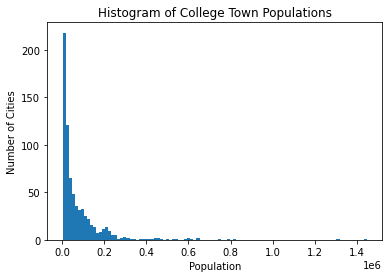

In [38]:
plt.title('Histogram of College Town Populations')
plt.xlabel('Population')
plt.ylabel('Number of Cities')
plt.hist(all_data_w_c.pop_2010, bins=100)
plt.show()

In [24]:
ninetyfive_ct = all_data_w_c.loc[ (all_data.pop_2010 <= all_data_w_c.pop_2010.quantile(.95)) ]

In [39]:
print( "Smallest college town 2010 population (lower 95%): {:.0f}".format( ninetyfive_ct.pop_2010.min() ) )
print( "Largest college town 2010 population (lower 95%): {:.0f}".format( ninetyfive_ct.pop_2010.max() ) )
print( "College towns with 2010 population (lower 95%): {:.0f}".format( ninetyfive_ct.pop_2010.count() ) )

Smallest college town 2010 population (lower 95%): 649
Largest college town 2010 population (lower 95%): 287065
College towns with 2010 population (lower 95%): 685


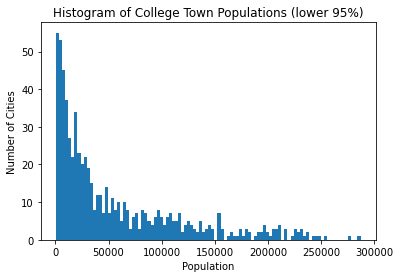

In [40]:
plt.title('Histogram of College Town Populations (lower 95%)')
plt.xlabel('Population')
plt.ylabel('Number of Cities')
plt.hist(ninetyfive_ct.pop_2010, bins=100)
plt.show()

## Comparing similarly sized Cities

From here forward, when comparing college town populations to the larger population data I will limit the dataset to cities with a known population of less than 250,000 so as to be comparing like samples.

In [47]:
dataset = all_data.loc[ ( all_data.pop_2010 < 250000 ) & (all_data['2020-09-30'] > 0)].drop(columns=['SizeRank', 'colleges'])

In [48]:
dataset.head()

,city,1996-01-31,1996-02-29,1996-03-31,1996-04-30,1996-05-31,1996-06-30,1996-07-31,1996-08-31,1996-09-30,...,pop_2011,pop_2012,pop_2013,pop_2014,pop_2015,pop_2016,pop_2017,pop_2018,pop_2019,colleges_count
20,Orlando,107166,107259,107439,107704,108108,108442,108731,108823,108903,...,243620.0,249935.0,255135.0,262469.0,270786.0,278512.0,281804.0,285903.0,287442.0,0
52,Knoxville,99599,99881,100134,100555,100909,101327,101728,102191,102503,...,179955.0,181093.0,181779.0,182631.0,184046.0,184986.0,186905.0,187362.0,187603.0,2
53,Baton Rouge,0,0,0,0,0,0,0,0,0,...,228643.0,228889.0,228346.0,227851.0,227202.0,226686.0,224414.0,222190.0,220236.0,3
63,Columbia,90962,91033,91094,91250,91368,91484,91589,91821,92056,...,131302.0,131761.0,131527.0,131781.0,133616.0,134129.0,134005.0,132770.0,131674.0,1
65,Marietta,147940,148096,148384,148971,149705,150394,150972,151473,151938,...,57348.0,58167.0,58819.0,59547.0,59845.0,60679.0,60679.0,60647.0,60867.0,0


In [49]:
# Save the final dataset
dataset.to_csv('working_dataset.csv')